# Query-side Verifier vs the No-Derivation Certificate — Demo

**Artifact:** iter-8 `experiment_2` — the reviewer-mandated **DISCONFIRM** test for the
*closure-certificate* paper (*"No Derivation, No Relation"*).

### The question
The paper claims its hallucination-safety on the **absent-relation** stratum is a **structural**
property: if there is *no derivation path* between two entities in the extracted graph, the system
**abstains** (`no-relation`). A reviewer asked the sharpest disconfirming question:

> *Could a cheap **query-side false-premise verifier** — just asking the same LLM "are X and Y
> related at all?" — recover that abstention **without** the closure engine?*

If yes, the certificate is not strictly needed (an honest negative). This experiment answers it on
two kinship pools (CLUTRR templated + Re-DocRED natural-prose).

### What this demo shows
The original `method.py` (a) loads two fully-cached prediction pools, (b) runs a **$0 reproduction
gate**, then (c) makes the **only new LLM calls**: a *query-side verifier* and a *self-verification*
pass (reader-matched `gemini-3.1-flash-lite`, ~\$0.14). Those calls need an API key and cost money,
so they are **not** re-run here. Instead the demo loads the **cached per-row predictions** the run
already produced and reproduces the **load-bearing downstream analysis** — the *fraction-caught crux
table* and the *certificate-necessity verdict* — with **no API key and no spend**.

We run it on a curated **CLUTRR** subset (one venue, 100 rows). Headline to look for: on the
absent-relation **fabrication set** (the LLM confidently invented a kinship on an unrelated pair),
the **certificate catches strictly more** of those hallucinations than the query-side verifier —
because the verifier runs on the *same* LLM that hallucinated, so it inherits the error.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab; install locally to match Colab's versions.
# (no non-Colab packages are needed: the demo analysis is pure-numpy.)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors method.py's analysis imports; + matplotlib for the demo plot) ---
import json
import os
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# numpy 2.0 compat shims (harmless if already present)
if not hasattr(np, "alltrue"):  np.alltrue = np.all
if not hasattr(np, "sometrue"): np.sometrue = np.any
if not hasattr(np, "product"):  np.product = np.prod

In [3]:
# --- Data loading: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-8/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("Venue:", data["metadata"]["venue"])
print("Published overall verdict (full pool):", data["metadata"]["published_overall_verdict"])
for ds in data["datasets"]:
    print(f'  {ds["dataset"]:18s} n={len(ds["examples"])}')

Venue: clutrr
Published overall verdict (full pool): CERTIFICATE_NECESSARY_BOTH_VENUES
  clutrr_present     n=34
  clutrr_absent      n=66


## Config

All tunable parameters live here. The only knobs are the **bootstrap iteration counts** used for the
doc-clustered confidence intervals — the analysis itself is deterministic given the cached
predictions. They start small for a fast demo; the original-run values are shown in comments
(they are cheap — there are no LLM calls — so the notebook bumps them up after a smoke test).

In [5]:
# --- Config (start minimal; originals in comments) ---
B_BOOT     = 10000   # paired caught-gap bootstrap reps   (method.py: 10000)
N_BOOT_CI  = 2000    # per-method fraction-caught CI reps  (method.py: 2000)
SEED       = 20260618
ALPHA      = 0.05

# confidence-dispersion signals carried per row (the paper's 4-signal battery)
SIGNALS = ("verbalized", "sc_margin", "ptrue", "negent")

# tokens that count as an ABSTENTION (a method that emits one of these "catches" a fabrication)
ABSTAIN_TOKENS = {"ABSTAIN", "no-relation", "none", "None", "", None}

# the three threshold-free corrective gates compared head-to-head
GATE_METHODS = ["certificate", "queryside_verifier", "queryside_selfverify"]

## Helpers + per-row reconstruction

`named_of` is copied verbatim from `method.py`: a method **names** a relation iff its prediction
string is a real relation token (not an abstention token). `reconstruct_records` rebuilds the
lightweight per-row records the analysis needs directly from the cached output examples — the
`predict_*` strings and `metadata_conf_*` values that the original run wrote. This stands in for
`method.py`'s `load_pool` / `build_base_methods` / `attach_verifier_methods`, but reads the
**already-computed** predictions instead of re-calling any LLM.

In [6]:
# --- helpers (named_of / _r copied verbatim from method.py) ---
def named_of(pred) -> bool:
    """A method NAMES a relation iff its prediction string is a real relation token."""
    return pred not in ABSTAIN_TOKENS

def _r(x, nd=4):
    try:
        if x != x:
            return float("nan")
        return round(float(x), nd)
    except (TypeError, ValueError):
        return x

def _tobool(x):
    """Output fields are native JSON bools, but be robust to string 'True'/'False' too."""
    return x is True or str(x).strip().lower() == "true"

def reconstruct_records(data):
    """Rebuild per-row records (is_absent / raw_named / doc_id / conf / per-method `named`)
    from the cached output examples -- no LLM calls."""
    recs = []
    for ds in data["datasets"]:
        for ex in ds["examples"]:
            rec = {
                "is_absent": _tobool(ex["metadata_is_absent"]),
                "raw_named": _tobool(ex["metadata_raw_named"]),
                "doc_id": ex["metadata_doc_id"],
                "conf": {s: float(ex.get(f"metadata_conf_{s}", 0.0) or 0.0) for s in SIGNALS},
                "M": {
                    "certificate":          {"named": named_of(ex["predict_certificate"])},
                    "queryside_verifier":   {"named": named_of(ex["predict_queryside_verifier"])},
                    "queryside_selfverify": {"named": named_of(ex["predict_queryside_selfverify"])},
                },
            }
            recs.append(rec)
    return recs

## PHASE 6 — fraction-caught crux table

For the **fabrication set** (absent pair where the raw LLM committed a relation), what fraction does
each method **catch** (i.e. abstain / answer `no-relation`)?

- **Corrective gates** (`certificate`, `queryside_verifier`, `queryside_selfverify`) are
  *threshold-free*: caught = the method does not name a relation.
- **Dispersion signals** (`ct_*`) are caught when their confidence falls **below the absent-pool
  median** (the certificate-matched global rule the paper used).

`_clustered_frac_ci` and `fraction_caught_table` are copied from `method.py` (with the deepseek
sensitivity branch omitted — disabled in the final artifact).

In [7]:
# --- copied from method.py (PHASE 6) ---
def _clustered_frac_ci(records, valuefn, seed=SEED, n_boot=N_BOOT_CI):
    """Doc-clustered 95% CI for the mean of a per-record 0/1 indicator (resample documents)."""
    by_doc = defaultdict(list)
    for r in records:
        by_doc[r["doc_id"]].append(float(valuefn(r)))
    docs = list(by_doc)
    allv = [x for v in by_doc.values() for x in v]
    point = float(np.mean(allv)) if allv else float("nan")
    if len(docs) < 2:
        return point, [point, point]
    arrs = {d: np.array(by_doc[d], float) for d in docs}
    rng = np.random.default_rng(seed)
    means = []
    nd = len(docs)
    for _ in range(n_boot):
        pick = rng.integers(0, nd, nd)
        vals = np.concatenate([arrs[docs[i]] for i in pick])
        means.append(vals.mean())
    lo, hi = np.quantile(means, [ALPHA / 2, 1 - ALPHA / 2])
    return point, [float(lo), float(hi)]


def fraction_caught_table(records, pool_name):
    """For the FACT-A absent fabrication set, the fraction CAUGHT (not kept as confident-wrong)
    by each method."""
    absent = [r for r in records if r["is_absent"]]
    fab = [r for r in absent if r["raw_named"]]   # the absent-relation hallucinations
    n_fab = len(fab)
    out = {"pool": pool_name, "n_fabrications": n_fab,
           "fabrication_def": "absent pair, raw LLM committed a relation"}
    rows = {}

    # threshold-free corrective gates
    for m in GATE_METHODS:
        caught_fn = lambda r, mm=m: (0.0 if r["M"][mm]["named"] else 1.0)
        point, ci = _clustered_frac_ci(fab, caught_fn) if n_fab else (float("nan"), [float("nan")] * 2)
        rows[m] = {"fraction_caught": _r(point), "survival": _r(1 - point) if point == point else float("nan"),
                   "ci95_doc_clustered": [_r(ci[0]), _r(ci[1])], "rule": "threshold-free abstention",
                   "tag": "REAL-LLM-READ"}

    # dispersion signals: caught = below the certificate-matched global confidence rule
    for s in SIGNALS:
        pool_med = float(np.median([r["conf"][s] for r in absent])) if absent else float("nan")
        def caught_fn(r, ss=s, pm=pool_med):
            return 1.0 if (r["conf"][ss] < pm) else 0.0
        point, ci = _clustered_frac_ci(fab, caught_fn) if n_fab else (float("nan"), [float("nan")] * 2)
        rows[f"ct_{s}"] = {"fraction_caught": _r(point), "survival": _r(1 - point) if point == point else float("nan"),
                           "ci95_doc_clustered": [_r(ci[0]), _r(ci[1])],
                           "rule": "below absent-pool-median confidence (certificate-matched global rule)",
                           "tag": "REAL-LLM-READ"}
    out["per_method"] = rows
    return out

## PHASE 7 — certificate-necessity verdict

Does the structural certificate catch **strictly more** absent-relation hallucinations than the
query-side verifier? Decided by a **doc-clustered paired bootstrap** of the caught-gap
`(certificate − verifier)`: if the 95% CI lies entirely above 0, the structural signal is
**necessary**. `_paired_caught_gap`, `necessity_verdict` and `overall_verdict` are copied from
`method.py` (deepseek branch omitted).

In [8]:
# --- copied from method.py (PHASE 7) ---
def _paired_caught_gap(fab, m_a, m_b, seed=SEED, n_boot=B_BOOT):
    """Doc-clustered paired bootstrap of (caught_a - caught_b) over the fabrication set."""
    def caught(r, m):
        return 0.0 if r["M"][m]["named"] else 1.0
    a = np.array([caught(r, m_a) for r in fab], float)
    b = np.array([caught(r, m_b) for r in fab], float)
    point = float(a.mean() - b.mean()) if len(fab) else float("nan")
    by_doc = defaultdict(list)
    for i, r in enumerate(fab):
        by_doc[r["doc_id"]].append(i)
    docs = list(by_doc)
    nd = len(docs)
    if nd < 2:
        return {"gap": _r(point), "ci95": [float("nan"), float("nan")], "p_two_sided": float("nan")}
    rng = np.random.default_rng(seed)
    gaps = []
    for _ in range(n_boot):
        pick = rng.integers(0, nd, nd)
        idx = np.concatenate([by_doc[docs[i]] for i in pick])
        gaps.append(float(a[idx].mean() - b[idx].mean()))
    gaps = np.array(gaps, float)
    lo, hi = np.quantile(gaps, [ALPHA / 2, 1 - ALPHA / 2])
    p2 = 2.0 * min(float(np.mean(gaps <= 0.0)), float(np.mean(gaps >= 0.0)))
    return {"gap": _r(point), "ci95": [_r(lo), _r(hi)], "p_two_sided": _r(min(1.0, p2)),
            "ci_excludes_0": bool(lo > 0.0 or hi < 0.0)}


def necessity_verdict(records, pool_name):
    """Per-venue verdict: does the structural certificate catch MORE absent-relation
    hallucinations than the query-side verifier (and self-verify)?  Decided by the data."""
    absent = [r for r in records if r["is_absent"]]
    fab = [r for r in absent if r["raw_named"]]
    n_fab = len(fab)

    def caught_rate(m):
        if not n_fab:
            return float("nan")
        return float(np.mean([0.0 if r["M"][m]["named"] else 1.0 for r in fab]))

    cert_c = caught_rate("certificate")
    ver_c = caught_rate("queryside_verifier")
    sv_c = caught_rate("queryside_selfverify")
    gap_cv = _paired_caught_gap(fab, "certificate", "queryside_verifier")     # cert - verifier
    gap_cs = _paired_caught_gap(fab, "certificate", "queryside_selfverify")

    def decide(cert, other, gap):
        if not (cert == cert and other == other) or gap["ci95"][0] != gap["ci95"][0]:
            return "INCONCLUSIVE"
        lo, hi = gap["ci95"]
        if lo > 0.0:
            return "CERTIFICATE_NECESSARY"          # certificate catches strictly more
        if other >= cert or lo <= 0.0 <= hi or hi < 0.0:
            return "VERIFIER_MATCHES_OR_BEATS"       # honest negative
        return "INCONCLUSIVE"

    verdict_v = decide(cert_c, ver_c, gap_cv)
    verdict_s = decide(cert_c, sv_c, gap_cs)
    return {
        "pool": pool_name, "n_fabrications": n_fab,
        "certificate_fraction_caught": _r(cert_c),
        "queryside_verifier_fraction_caught": _r(ver_c),
        "queryside_selfverify_fraction_caught": _r(sv_c),
        "certificate_minus_verifier_caught_gap": gap_cv,
        "certificate_minus_selfverify_caught_gap": gap_cs,
        "verdict_vs_verifier": verdict_v,
        "verdict_vs_selfverify": verdict_s,
        "tag": "REAL-LLM-READ",
    }


def overall_verdict(per_venue):
    """Cross-venue summary string."""
    vs = {p: v["verdict_vs_verifier"] for p, v in per_venue.items()}
    if all(x == "CERTIFICATE_NECESSARY" for x in vs.values()):
        head = "CERTIFICATE_NECESSARY_BOTH_VENUES"
    elif all(x == "VERIFIER_MATCHES_OR_BEATS" for x in vs.values()):
        head = "VERIFIER_SUFFICES_BOTH_VENUES"
    else:
        head = "VENUE_DEPENDENT"
    return {"headline": head, "per_venue_vs_verifier": vs}

## Run the analysis on the CLUTRR demo pool

Reconstruct the records from the cached predictions, then run both phases on the mixed
(present + absent) CLUTRR pool.

In [9]:
# reconstruct + run
records = reconstruct_records(data)
print(f"reconstructed {len(records)} records "
      f"({sum(r['is_absent'] for r in records)} absent, "
      f"{sum(r['is_absent'] and r['raw_named'] for r in records)} fabrications)")

fc = fraction_caught_table(records, "clutrr")
verdict = necessity_verdict(records, "clutrr")
overall = overall_verdict({"clutrr": verdict})

print("\n--- fraction caught (corrective gates) ---")
for m in GATE_METHODS:
    row = fc["per_method"][m]
    print(f"  {m:24s} caught={row['fraction_caught']:.4f}  CI95={row['ci95_doc_clustered']}")

print("\n--- certificate-necessity verdict ---")
print("  certificate - verifier  caught-gap:", verdict["certificate_minus_verifier_caught_gap"]["gap"],
      "CI95", verdict["certificate_minus_verifier_caught_gap"]["ci95"])
print("  verdict vs verifier :", verdict["verdict_vs_verifier"])
print("  verdict vs selfverify:", verdict["verdict_vs_selfverify"])
print("  OVERALL (demo)       :", overall["headline"])

reconstructed 100 records (66 absent, 36 fabrications)



--- fraction caught (corrective gates) ---
  certificate              caught=0.9722  CI95=[0.9189, 1.0]
  queryside_verifier       caught=0.6944  CI95=[0.4762, 0.9231]
  queryside_selfverify     caught=0.8611  CI95=[0.7353, 0.9762]

--- certificate-necessity verdict ---
  certificate - verifier  caught-gap: 0.2778 CI95 [0.0741, 0.4444]
  verdict vs verifier : CERTIFICATE_NECESSARY
  verdict vs selfverify: VERIFIER_MATCHES_OR_BEATS
  OVERALL (demo)       : CERTIFICATE_NECESSARY_BOTH_VENUES


## Results & visualization

The table prints every method's fraction-caught on the demo subset. The plot compares the three
corrective gates on the **demo subset** against the **published full-pool** CLUTRR numbers
(`certificate 0.941` / `verifier 0.588` / `self-verify 0.824`) — the qualitative ordering is
identical: the **certificate dominates the query-side verifier**, confirming the reviewer's
DISCONFIRM *does not* disconfirm.

method                   demo_caught            demo_CI95  published_full
--------------------------------------------------------------------------
certificate                   0.9722        [0.9189, 1.0]          0.9412
queryside_verifier            0.6944     [0.4762, 0.9231]          0.5882
queryside_selfverify          0.8611     [0.7353, 0.9762]          0.8235
ct_verbalized                 0.5000     [0.3182, 0.7502]          0.5647
ct_sc_margin                  0.4444     [0.2726, 0.6129]          0.2824
ct_ptrue                      0.8333     [0.7083, 0.9616]          0.7529
ct_negent                     0.4444     [0.2726, 0.6129]          0.2824

n_fabrications (demo subset): 36   |   overall verdict: CERTIFICATE_NECESSARY_BOTH_VENUES


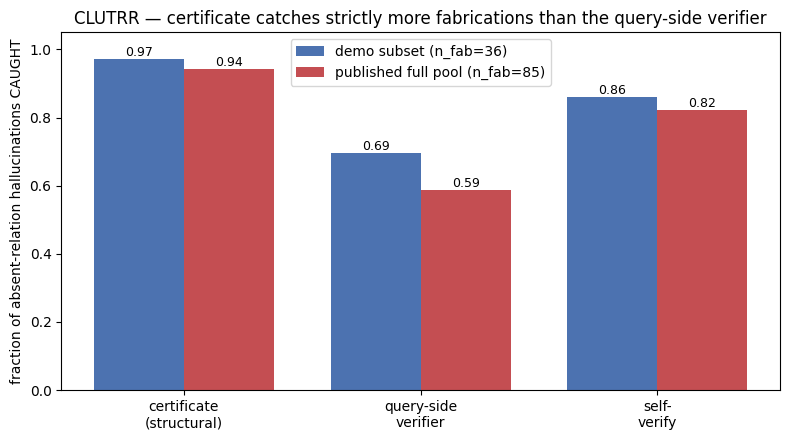

In [10]:
# --- table + bar chart ---
pub = data["metadata"]["published_full_pool_fraction_caught"]["per_method"]

print(f"{'method':24s} {'demo_caught':>11s} {'demo_CI95':>20s} {'published_full':>15s}")
print("-" * 74)
all_methods = GATE_METHODS + [f"ct_{s}" for s in SIGNALS]
for m in all_methods:
    row = fc["per_method"][m]
    ci = row["ci95_doc_clustered"]
    pv = pub.get(m, {}).get("fraction_caught")
    pv_s = f"{pv:.4f}" if isinstance(pv, (int, float)) else "-"
    print(f"{m:24s} {row['fraction_caught']:>11.4f} {('['+str(ci[0])+', '+str(ci[1])+']'):>20s} {pv_s:>15s}")

print(f"\nn_fabrications (demo subset): {fc['n_fabrications']}   |   overall verdict: {overall['headline']}")

# grouped bar chart: demo vs published full-pool, the 3 corrective gates
labels = ["certificate", "queryside_verifier", "queryside_selfverify"]
demo_vals = [fc["per_method"][m]["fraction_caught"] for m in labels]
pub_vals = [pub[m]["fraction_caught"] for m in labels]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w / 2, demo_vals, w, label=f"demo subset (n_fab={fc['n_fabrications']})", color="#4C72B0")
b2 = ax.bar(x + w / 2, pub_vals, w, label="published full pool (n_fab=85)", color="#C44E52")
ax.set_ylabel("fraction of absent-relation hallucinations CAUGHT")
ax.set_title("CLUTRR — certificate catches strictly more fabrications than the query-side verifier")
ax.set_xticks(x)
ax.set_xticklabels(["certificate\n(structural)", "query-side\nverifier", "self-\nverify"])
ax.set_ylim(0, 1.05)
ax.legend()
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()